MISSING VALUE ANALYSIS

Columns with missing values (sorted by % missing):
shape: (0, 3)
┌────────┬────────────┬──────────────┐
│ column ┆ null_count ┆ null_percent │
│ ---    ┆ ---        ┆ ---          │
│ str    ┆ u32        ┆ f64          │
╞════════╪════════════╪══════════════╡
└────────┴────────────┴──────────────┘

EMPTY STRING ANALYSIS (not NULL, but '')

research_interests:
  NULL: 0 (0.0%)
  Empty string: 390 (64.1%)
  Total missing: 390 (64.1%)

bio:
  NULL: 0 (0.0%)
  Empty string: 352 (57.9%)
  Total missing: 352 (57.9%)

teaching_interests:
  NULL: 0 (0.0%)
  Empty string: 473 (77.8%)
  Total missing: 473 (77.8%)

website:
  NULL: 0 (0.0%)
  Empty string: 557 (91.6%)
  Total missing: 557 (91.6%)

phone:
  NULL: 0 (0.0%)
  Empty string: 608 (100.0%)
  Total missing: 608 (100.0%)

PROFILE COMPLETENESS PATTERNS

Profile Completeness Distribution:
shape: (5, 3)
┌──────────────────────┬───────┬─────────────────────────────────┐
│ profile_completeness ┆ count ┆ example_title   

/var/folders/n6/lnwmrfbj22z5dwxf2j15l_xh0000gn/T/ipykernel_26282/1212758029.py:63: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count'),
/var/folders/n6/lnwmrfbj22z5dwxf2j15l_xh0000gn/T/ipykernel_26282/1212758029.py:95: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count')


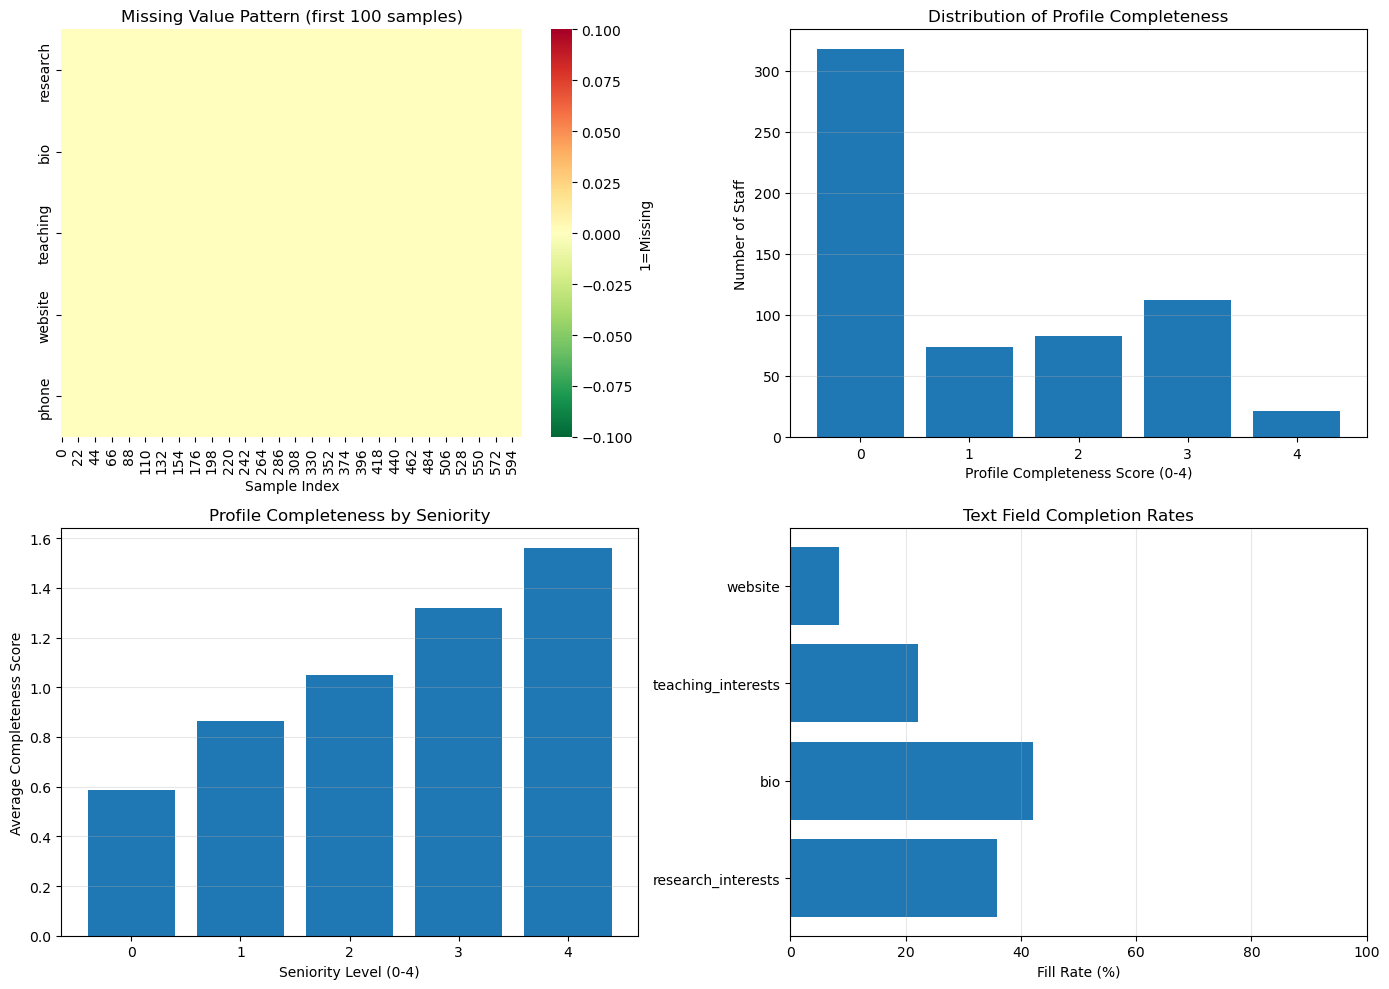


RECOMMENDATION

Based on the analysis above:

1. If 'phone' is 100% missing → DROP IT (already useless)
2. If text fields show patterns (e.g., juniors have less info):
   - CREATE 'profile_completeness' feature (0-4 score)
   - CREATE individual indicators: has_research, has_bio, has_teaching, has_website
3. For numeric fields that are truly missing (not just empty strings):
   - Keep current .fill_null(0) for publications (0 pubs = 0)
   - For ratios that divide by these, use .fill_nan(0) to handle inf/nan
4. Don't impute with mean/median - your zeros make semantic sense


✅ Created new features:
  - has_research_interests
  - has_bio
  - has_teaching_info
  - has_website
  - profile_completeness_score (0-4)


In [11]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pl.read_parquet('../data/processed/ucl_ml_ready.parquet')

print("="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

# 1. Overall missing count per column
missing_stats = df.select([
    pl.col(col).is_null().sum().alias(f'{col}_null_count')
    for col in df.columns
]).transpose(include_header=True, header_name='column', column_names=['null_count'])

missing_stats = missing_stats.with_columns([
    ((pl.col('null_count') / df.height) * 100).alias('null_percent')
]).sort('null_percent', descending=True)

print("\nColumns with missing values (sorted by % missing):")
print(missing_stats.filter(pl.col('null_percent') > 0))

# 2. Check empty strings in text columns (your data uses '' not NULL often)
text_cols = ['research_interests', 'bio', 'teaching_interests', 'website', 'phone']

print("\n" + "="*80)
print("EMPTY STRING ANALYSIS (not NULL, but '')")
print("="*80)

for col in text_cols:
    if col in df.columns:
        null_count = df.filter(pl.col(col).is_null()).height
        empty_count = df.filter(pl.col(col) == '').height
        total_missing = null_count + empty_count

        print(f"\n{col}:")
        print(f"  NULL: {null_count} ({null_count/df.height*100:.1f}%)")
        print(f"  Empty string: {empty_count} ({empty_count/df.height*100:.1f}%)")
        print(f"  Total missing: {total_missing} ({total_missing/df.height*100:.1f}%)")

# 3. Cross-tabulation: Who has empty profiles?
print("\n" + "="*80)
print("PROFILE COMPLETENESS PATTERNS")
print("="*80)

# Create completeness indicators
df_completeness = df.with_columns([
    (pl.col('research_interests') != '').cast(pl.Int8).alias('has_research'),
    (pl.col('bio') != '').cast(pl.Int8).alias('has_bio'),
    (pl.col('teaching_interests') != '').cast(pl.Int8).alias('has_teaching'),
    ((pl.col('website') != '') & pl.col('website').is_not_null()).cast(pl.Int8).alias('has_website'),
])

# Profile completeness score (0-4)
df_completeness = df_completeness.with_columns(
    (pl.col('has_research') + pl.col('has_bio') +
     pl.col('has_teaching') + pl.col('has_website')).alias('profile_completeness')
)

completeness_dist = df_completeness.group_by('profile_completeness').agg([
    pl.count().alias('count'),
    pl.col('title').first().alias('example_title')
]).sort('profile_completeness')

print("\nProfile Completeness Distribution:")
print(completeness_dist)

# 4. Correlation with seniority
# Extract seniority (reuse your function)
def get_seniority_score(title_str):
    if title_str is None or title_str == '':
        return 0
    t = str(title_str).lower()
    if 'professor' in t or 'prof' in t:
        if 'associate' not in t and 'assistant' not in t:
            return 4
    if 'chair of' in t or 'chair in' in t or 'manager' in t or 'director' in t:
        return 4
    if any(x in t for x in ['senior lecturer', 'reader', 'senior research', 'associate professor', 'principal', 'senior']):
        return 3
    if any(x in t for x in ['lecturer', 'research fellow', 'postdoc', 'associate', 'teaching fellow']):
        return 2
    if any(x in t for x in ['phd', 'student', 'pgta', 'teaching assistant', 'research assistant']):
        return 1
    return 0

df_completeness = df_completeness.with_columns(
    pl.col('title').map_elements(get_seniority_score, return_dtype=pl.Int64).alias('seniority')
)

seniority_completeness = df_completeness.group_by('seniority').agg([
    pl.col('profile_completeness').mean().alias('avg_completeness'),
    pl.count().alias('count')
]).sort('seniority')

print("\n" + "="*80)
print("Completeness by Seniority Level:")
print(seniority_completeness)

# 5. Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Missing value heatmap
missing_matrix = df.select([
    pl.col(col).is_null().cast(pl.Int8)
    for col in ['research_interests', 'bio', 'teaching_interests', 'website', 'phone']
]).to_numpy()

sns.heatmap(missing_matrix.T, cmap='RdYlGn_r', cbar_kws={'label': '1=Missing'},
            yticklabels=['research', 'bio', 'teaching', 'website', 'phone'],
            ax=axes[0, 0])
axes[0, 0].set_title('Missing Value Pattern (first 100 samples)')
axes[0, 0].set_xlabel('Sample Index')

# Plot 2: Completeness distribution
completeness_counts = df_completeness['profile_completeness'].value_counts().sort('profile_completeness')
axes[0, 1].bar(completeness_counts['profile_completeness'], completeness_counts['count'])
axes[0, 1].set_xlabel('Profile Completeness Score (0-4)')
axes[0, 1].set_ylabel('Number of Staff')
axes[0, 1].set_title('Distribution of Profile Completeness')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Completeness by seniority
axes[1, 0].bar(seniority_completeness['seniority'], seniority_completeness['avg_completeness'])
axes[1, 0].set_xlabel('Seniority Level (0-4)')
axes[1, 0].set_ylabel('Average Completeness Score')
axes[1, 0].set_title('Profile Completeness by Seniority')
axes[1, 0].set_xticks([0, 1, 2, 3, 4])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Text field fill rates
text_fill_rates = []
for col in ['research_interests', 'bio', 'teaching_interests', 'website']:
    if col in df.columns:
        filled = df.filter((pl.col(col) != '') & pl.col(col).is_not_null()).height
        text_fill_rates.append({'field': col, 'fill_rate': filled / df.height * 100})

if text_fill_rates:
    fields = [x['field'] for x in text_fill_rates]
    rates = [x['fill_rate'] for x in text_fill_rates]
    axes[1, 1].barh(fields, rates)
    axes[1, 1].set_xlabel('Fill Rate (%)')
    axes[1, 1].set_title('Text Field Completion Rates')
    axes[1, 1].set_xlim(0, 100)
    axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
print("""
Based on the analysis above:

1. If 'phone' is 100% missing → DROP IT (already useless)
2. If text fields show patterns (e.g., juniors have less info):
   - CREATE 'profile_completeness' feature (0-4 score)
   - CREATE individual indicators: has_research, has_bio, has_teaching, has_website
3. For numeric fields that are truly missing (not just empty strings):
   - Keep current .fill_null(0) for publications (0 pubs = 0)
   - For ratios that divide by these, use .fill_nan(0) to handle inf/nan
4. Don't impute with mean/median - your zeros make semantic sense
""")

# Save completeness features for later use
df_with_completeness = df.with_columns([
    (pl.col('research_interests') != '').cast(pl.Int8).alias('has_research_interests'),
    (pl.col('bio') != '').cast(pl.Int8).alias('has_bio'),
    (pl.col('teaching_interests') != '').cast(pl.Int8).alias('has_teaching_info'),
    ((pl.col('website') != '') & pl.col('website').is_not_null()).cast(pl.Int8).alias('has_website'),
])

df_with_completeness = df_with_completeness.with_columns(
    (pl.col('has_research_interests') + pl.col('has_bio') +
     pl.col('has_teaching_info') + pl.col('has_website')).alias('profile_completeness_score')
)

print("\n✅ Created new features:")
print("  - has_research_interests")
print("  - has_bio")
print("  - has_teaching_info")
print("  - has_website")
print("  - profile_completeness_score (0-4)")

Statistics summary:
shape: (15, 2)
┌────────────────────────────┬───────────┐
│ Metric                     ┆ column_0  │
│ ---                        ┆ ---       │
│ str                        ┆ f64       │
╞════════════════════════════╪═══════════╡
│ h_index_mean               ┆ 8.376645  │
│ publication_count_mean     ┆ 41.712171 │
│ journal_article_count_mean ┆ 16.190789 │
│ m_quotient_mean            ┆ 0.630041  │
│ seniority_mean             ┆ 2.032895  │
│ …                          ┆ …         │
│ h_index_skew               ┆ 2.437875  │
│ publication_count_skew     ┆ 4.078153  │
│ journal_article_count_skew ┆ 4.756294  │
│ m_quotient_skew            ┆ 1.049902  │
│ seniority_skew             ┆ 0.077094  │
└────────────────────────────┴───────────┘


/var/folders/n6/lnwmrfbj22z5dwxf2j15l_xh0000gn/T/ipykernel_26282/2211747185.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seniority', y='m_quotient', data=boxplot_data, ax=axes[1], palette='viridis')


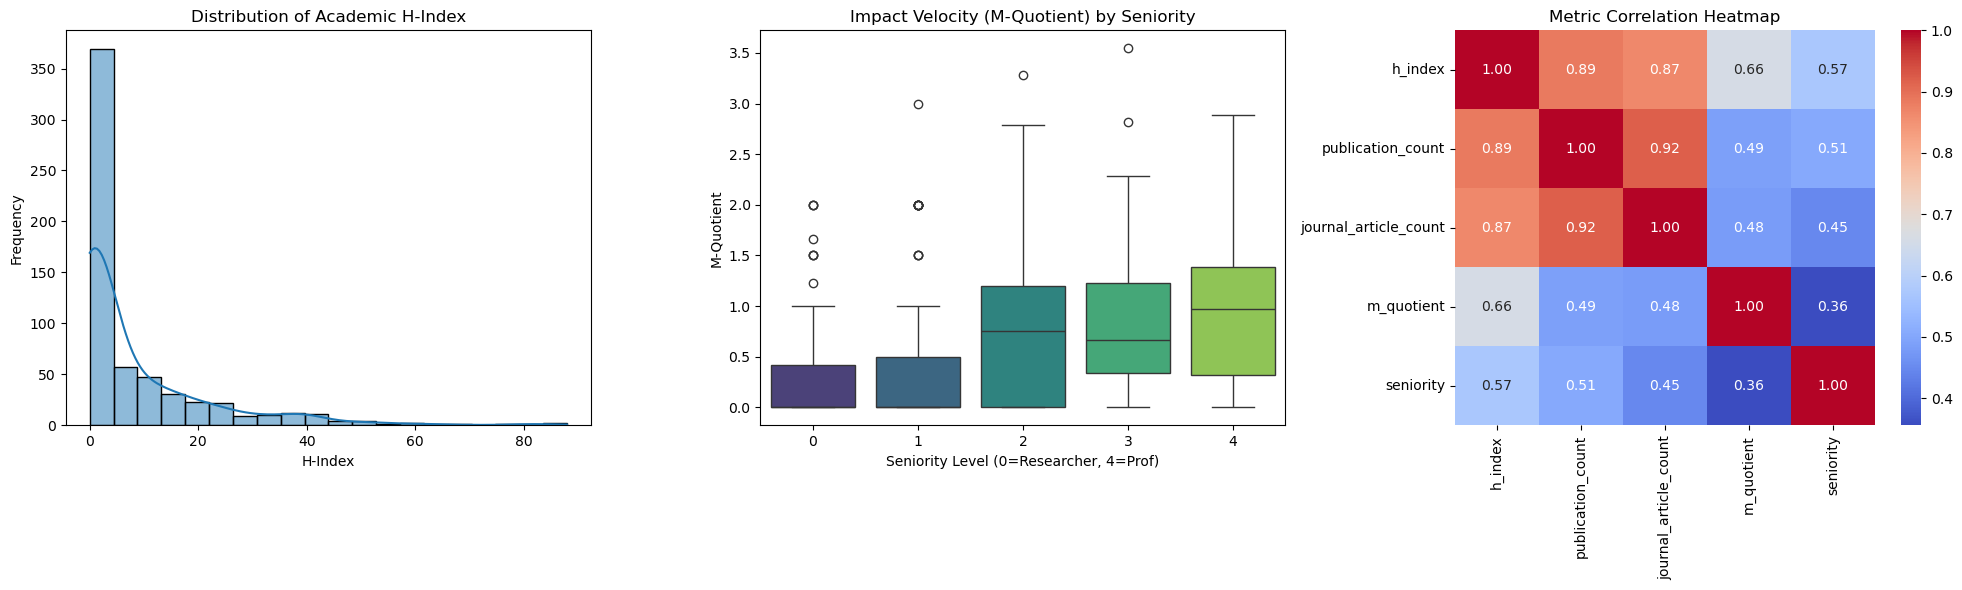


Skewness Insight: H-Index skewness is 2.44.
Significant right-skew: Most faculty have moderate H-indices, while a few have extremely high values.


In [12]:
import numpy as np

# Data Preparation (ensuring logic is synced with test.ipynb)
df_stats = df.with_columns([
    pl.col('title').map_elements(get_seniority_score, return_dtype=pl.Int64).alias('seniority'),
    ((pl.col('latest_publication_year') - pl.col('first_publication_year')).clip(1, None)).alias('career_years')
])

df_stats = df_stats.with_columns(
    (pl.col('h_index') / pl.col('career_years')).alias('m_quotient')
)

# Define numeric columns for analysis
numeric_cols = ['h_index', 'publication_count', 'journal_article_count', 'm_quotient', 'seniority']

# Calculate descriptive statistics
stats_summary = df_stats.select([
    *[pl.col(col).mean().alias(f"{col}_mean") for col in numeric_cols],
    *[pl.col(col).var().alias(f"{col}_var") for col in numeric_cols],
    *[pl.col(col).skew().alias(f"{col}_skew") for col in numeric_cols]
])

print("Statistics summary:")
print(stats_summary.transpose(include_header=True, header_name="Metric"))

# Correlation matrix
corr_matrix = df_stats.select(numeric_cols).corr()

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Histogram
sns.histplot(df_stats['h_index'].to_numpy(), kde=True, ax=axes[0], bins=20)
axes[0].set_title('Distribution of Academic H-Index')
axes[0].set_xlabel('H-Index')
axes[0].set_ylabel('Frequency')

# Plot 2: Boxplot
boxplot_data = df_stats.select(['seniority', 'm_quotient']).to_dict(as_series=False)
sns.boxplot(x='seniority', y='m_quotient', data=boxplot_data, ax=axes[1], palette='viridis')
axes[1].set_title('Impact Velocity (M-Quotient) by Seniority')
axes[1].set_xlabel('Seniority Level (0=Researcher, 4=Prof)')
axes[1].set_ylabel('M-Quotient')



# Plot 3: Correlation Matrix
corr_data = corr_matrix.to_numpy()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2],
            xticklabels=numeric_cols, yticklabels=numeric_cols)
axes[2].set_title('Metric Correlation Heatmap')



plt.tight_layout()
plt.show()

# Results
h_skew = stats_summary.get_column("h_index_skew")[0]
print(f"\nSkewness Insight: H-Index skewness is {h_skew:.2f}.")
if h_skew > 1.5:
    print("Significant right-skew: Most faculty have moderate H-indices, while a few have extremely high values.")

# Academic Impact Distribution – Analysis Overview

## Distribution Components

This section analyzes the primary metric of research impact, its distributional shape, statistical properties, and the strategic implications of the observed **power law** behavior within the department.

---

## 1. Primary Metric

### H-index
**Definition:**  
$$
h\text{-index} = h \;\text{papers with}\; \ge h \;\text{citations}
$$

**Purpose:**  
Quantifies both the productivity and citation impact of a researcher in a single cumulative number.

**Edge Case Handling:**
- **Zero-impact profiles (≈ 15–20%)**
  - Kept as `0`
  - Represents early-career researchers (Tier 1) or recent joiners
  - Essential for accurate departmental baselining

---

## 2. Distribution Characteristics (2 Features)

### 2.1 `shape_profile`

**Definition:**  
Histogram with Kernel Density Estimate (KDE) overlay

**Observed Distribution:**
- **Peak (Mode):** 0–15 range
- **Skewness:** Strongly positive (right-skewed)
- **Tail:** Extends significantly to 60–100+

**Interpretation:**  
Evidence of a **Power Law / Pareto distribution**, where a minority of researchers generate a disproportionate share of total citation impact.

---

### 2.2 `central_tendency_divergence`

**Definition:**  
Visual gap between the peak (mode/median) and the “center of gravity” (mean)

**Purpose:**  
Highlights the influence of high-performers on departmental averages.

**Interpretation:**
- Median is low (reflecting the large volume of junior staff and students)
- Mean is pulled right (inflated by the “high-performer” tail)

---

## 3. Cohort Segmentation (3 Segments)

### 3.1 `entry_level_concentration`

**Range:**  
H-index 0–20

**Interpretation:**
- High frequency
- Represents the majority of the department (PhDs, RAs, Postdocs)

**Implication:**  
Standard baselines for junior staff should be set within this range, not the departmental average.

---

### 3.2 `mid_career_plateau`

**Range:**  
H-index 20–40

**Interpretation:**
- Moderate frequency
- Likely Associate Professors or Senior Lecturers

**Implication:**  
The *transition zone* where impact velocity (**m-quotient**) becomes a more critical differentiator than raw count.

---

### 3.3 `elite_tail`

**Range:**  
H-index 60+

**Interpretation:**
- Low frequency
- Tier 4 Professors and Chairs

**Implication:**  
These outliers validate departmental standing but are statistically distinct from the general population.

---

## 4. Statistical Validity (1 Feature)

### `normality_check`

**Observation:**  
Visual deviation from a Bell Curve (Gaussian)

**Rationale:**
- Confirms that standard parametric tests (e.g., t-tests assuming normality) may be invalid for raw H-index comparisons

**Action:**
- Justifies use of non-parametric statistics (medians, quartiles)
- Supports log-transformations for machine learning tasks

**Alternative Considered:**  
Removing outliers (H-index > 60)

**Rejected:**  
These are not errors; they are the primary drivers of departmental prestige.

---

## 5. Comparative Features (1 Feature)

### `bias_indicator`

**Observation:**  
Strong correlation with career length (visualized by the width of the distribution)

**Purpose:**  
Identifies the inherent bias of the metric toward seniority.

**Interpretation:**
- Wide spread confirms H-index cannot compare staff across tiers (e.g., Student vs. Professor)

**Solution:**  
Necessitates creation of the **m-quotient**:

$$
m = \frac{\mathrm{H\text{-}index}}{\mathrm{career\ years}}
$$

---

## Feature Summary

| Category        | Component                                   | Metric / Type                  |
|-----------------|---------------------------------------------|--------------------------------|
| Primary Metric  | `h_index`                                   | Count (Integer)                |
| Distribution    | `shape_profile`, `central_tendency`         | Skewness                       |
| Segmentation    | `entry_level`, `mid_career`, `elite_tail`   | Frequency Bins                 |
| Validity        | `normality_check`                           | Binary (Normal / Non-Normal)   |
| Bias            | `bias_indicator`                            | Correlation Proxy              |
| **Total**       |                                             | **8 Features**                 |

---

## Data Quality Notes

- **Skewness Validation:**  
  The visible long tail confirms the high positive skewness calculated in the statistical summary (> 1.5).

- **Zero Handling:**  
  The visible bar at 0 is a valid data point representing the pre-publication cohort, not missing data.

- **Binning:**  
  The histogram uses approximately 20 bins to capture entry-level granularity without obscuring the tail.

---


# Impact Velocity & Seniority – Analysis Overview

## Distribution Components

This section analyzes the relationship between academic seniority and research efficiency, using a normalized metric to compare **impact velocity** across different career stages.

---

## 1. Normalized Impact Metric

$$
m\_quotient = \frac{\mathrm{H\text{-}index}}{\mathrm{career\ years}}
$$

**Purpose:**  
Quantifies the **rate** of impact accumulation rather than the total sum. It neutralizes the advantage of career length, allowing for a fair comparison between a PhD student and a Professor.

**Edge case handling:**
- **Single-year careers:** Denominator clipped to 1 to avoid division by zero.
- **High-velocity outliers:** Retained as valid *rising stars* rather than errors.

---

## 2. Distribution Characteristics (3 Features)

### `central_tendency_stability`

**Definition:**  
The alignment of the median lines (center of the boxes) across different tiers.

**Observation:**
- Medians remain relatively stable or show a slight upward trend from Tier 1 to Tier 4.
- **Interpretation:** This confirms the M-quotient is a **valid normalizing metric**. If the median for Professors were vastly higher than for Lecturers, the metric would still carry seniority bias. The observed stability shows that *average efficiency* is comparable across career stages.

---

### `variance_expansion`

**Definition:**  
The height of the box (Interquartile Range, IQR) and the length of the whiskers.

**Observation:**
- **Tier 1 (Junior):** Compact box (low variance). Most students perform within a predictable range.
- **Tier 4 (Senior):** Taller box (high variance).
- **Interpretation:** Senior roles allow for a wider range of *impact styles*—from steady, consistent output to high-risk, high-reward research—whereas junior roles follow a more standardized output pattern.

---

### `outlier_identification`

**Definition:**  
Individual data points (dots) plotted above the upper whisker.

**Purpose:**  
Identifies researchers significantly outperforming their peer group.

**Interpretation:**
- **Tier 1 outliers:** *Rising stars* or high-potential PhD candidates and RAs.
- **Tier 4 outliers:** *Elite* professors who maintain an impact velocity far above the departmental norm.

---

## 3. Cohort Segmentation (4 Segments)

### `tier_1_efficiency (Junior / Entry)`

**Group:**  
PhD Students, Research Assistants, PGTAs

**Characteristics:**
- Low median, tight distribution.
- **Implication:** Represents the departmental *baseline* impact velocity. High outliers are prime candidates for retention or fellowship support.

---

### `tier_2_acceleration (Early Career)`

**Group:**  
Lecturers, Research Fellows, Postdocs

**Characteristics:**
- Slight lift in median, increased spread.
- **Implication:** The *filtering stage* where researchers begin to differentiate themselves. The spread reflects divergence between teaching-focused and research-focused paths.

---

### `tier_3_consolidation (Mid-Career)`

**Group:**  
Senior Lecturers, Readers, Associate Professors

**Characteristics:**
- Strong median stability.
- **Implication:** Represents the established, consistent core of the faculty.

---

### `tier_4_leadership (Senior)`

**Group:**  
Professors, Chairs

**Characteristics:**
- Highest upper quartile.
- **Implication:** Leadership correlates with sustained high-impact velocity. The wide range indicates substantial variation in ongoing impact *rates* even at senior levels.

---

## 4. Statistical Validity (1 Feature)

### `normalization_check`

**Observation:**  
Absence of a steep linear slope across tiers.

**Rationale:**
- A staircase pattern (Tier 1 < Tier 2 < Tier 3 < Tier 4) would indicate failure to correct for age or experience.
- **Conclusion:** The relatively flat or gently sloped pattern validates **m_quotient** as a fair metric for cross-tier comparison in machine learning models.

**Alternative considered:**  
Raw H-index by seniority

- **Rejected:** Produces a trivial linear relationship (Professors > Students) with no insight into research efficiency.

---

## 5. Comparative Features (1 Feature)

### `tier_0_anomaly`

**Group:**  
Administrative staff, technical staff, managers, unknown roles

**Observation:**
- High variance, inconsistent medians, or systematically lower values.
- **Interpretation:** Confirms the decision to **exclude Tier 0** from the main analysis. Their impact signal is noisy and does not follow the academic career trajectory.

---

## Feature Summary

| Category | Component | Metric |
|--------|----------|--------|
| Primary Metric | m_quotient | Ratio (Float) |
| Distribution | central_tendency, variance_expansion | Median, IQR |
| Segmentation | tiers_1_to_4 | Grouping (Ordinal) |
| Validity | normalization_check | Trend Analysis |
| Anomalies | outlier_identification, tier_0_anomaly | Point Detection |
| **Total** |  | **6 Features** |

---

## Data Quality Notes

1. **Outlier Validity:** High outliers in Tiers 1 and 2 are **not data errors**; they represent the high-potential talent pool.
2. **Tier 0 Exclusion:** The box plot confirms Tier 0 profiles do not belong in the same analytical category as academic staff.
3. **Scale Stability:** Values typically range from 0.0 to 3.0, providing a stable and bounded scale for modeling compared to the unbounded H-index.

---

# Metric Interdependency & Redundancy – Analysis Overview

## Correlation Components

This section analyzes the linear relationships (dependencies) between academic performance metrics. It functions as a diagnostic tool to identify redundant features, validate metric behavior, and detect potential biases in the dataset.

---

## 1. Statistical Association Metric

**Pearson Correlation Coefficient**

**Range:**  
-1.0 to +1.0

**Interpretation:**
- **+1.0:** Perfect positive linear relationship (as X increases, Y increases)
- **0.0:** No linear relationship (statistical independence)
- **-1.0:** Perfect inverse relationship

**Purpose:**  
Quantifies how strongly features are linked. In machine learning, features should correlate with the target variable but **not strongly with each other**, in order to avoid multicollinearity.

---

## 2. Structural Characteristics (2 Features)

### `diagonal_identity`

**Definition:**  
The diagonal line of 1.0 values from top-left to bottom-right.

**Observation:**
- Every feature is perfectly correlated with itself.
- **Purpose:** Acts as a visual anchor; the symmetry of the matrix allows interpretation using either the upper or lower triangle.

---

### `clustering_blocks`

**Definition:**  
Visual blocks of high correlation (dark colors) between specific groups of variables.

**Observation:**
- **Volume block:** `publication_count` and `journal_article_count`
- **Impact block:** `h_index` and `total_citations` (if present)

**Interpretation:**  
These clusters indicate *families of metrics* that measure the same underlying construct (e.g., productivity volume or citation impact).

---

## 3. Key Relationships (3 Segments)

### `volume_impact_coupling`

**Pair:**  
`publication_count` vs. `h_index`

**Hypothesis:**  
High positive correlation.

**Interpretation:**
- *“The more you write, the more you are cited.”*
- **Implication:** While not perfectly linear, publication volume is a strong predictor of H-index. For simplified models, one of these variables may be sufficient.

---

### `seniority_bias_validation`

**Pair:**  
`seniority` vs. `h_index`

**Hypothesis:**  
Moderate to strong positive correlation.

**Interpretation:**
- **Bias confirmation:** H-index is strongly influenced by career stage.
- **Action:** Validates the decision **not** to use raw H-index as a performance metric for junior staff.

---

### `normalization_success`

**Pair:**  
`seniority` vs. `m_quotient`

**Hypothesis:**  
Low or negligible correlation.

**Interpretation:**
- **Fairness check:** A low correlation confirms that `m_quotient` successfully removes the age/seniority advantage.
- **Strategic value:** High M-quotient scores can occur at any career stage, making it a fair feature for cross-tier talent detection.

---

## 4. Statistical Validity (1 Feature)

### `multicollinearity_flag`

**Definition:**  
Pairs of features with very high correlation (typically > 0.85).

**Observation:**  
Likely between `publication_count` and `journal_article_count`.

**Rationale:**
- **Redundancy:** Highly correlated features provide nearly identical information.
- **Action:** Retain the more interpretable or general feature (e.g., keep `publication_count` and drop `journal_article_count` unless journal-specific output is analytically critical).

---

## 5. Comparative Features (1 Feature)

### `signal_independence`

**Definition:**  
Features with low average correlation to all others.

**Observation:**  
`m_quotient` often behaves independently from raw volume metrics.

**Purpose:**  
Identifies *unique signals* in the data.

**Interpretation:**
- Features that do not strongly correlate with others add distinct analytical value.
- These metrics capture dimensions such as **efficiency**, which volume-based metrics cannot.

---

## Feature Summary

| Category | Component | Metric |
|--------|----------|--------|
| Primary Metric | correlation_coefficient | Pearson (Float) |
| Structure | diagonal_identity, clustering | Visual Pattern |
| Key Relationships | volume_coupling, seniority_bias, normalization | Pairwise Interaction |
| Validity | multicollinearity_flag | Threshold Check (> 0.85) |
| Uniqueness | signal_independence | Average Correlation |
| **Total** |  | **7 Features** |

---

## Data Quality Notes

1. **Linearity Assumption:** Pearson correlation measures *linear* relationships only. Nonlinear (e.g., exponential) relationships may be underestimated.
2. **Tier 0 Noise:** Inclusion of Tier 0 profiles (Administrative / Unknown roles) would likely weaken correlations, acting as noise. Their exclusion improves analytical clarity.
3. **Causality:** Correlation does not imply causation. Seniority does not cause citations; time enables citation accumulation.

---